<a href="https://colab.research.google.com/github/fatmazaarour/BITCOIN2/blob/main/bitcoin_empirical_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [20]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson


In [21]:
from google.colab import files

uploaded = files.upload()

Saving data.xlsx to data (1).xlsx


In [22]:
import pandas as pd

df = pd.read_excel("data.xlsx")
df["observation_date"] = pd.to_datetime(df["observation_date"])
df = df.sort_values("observation_date").set_index("observation_date")

for c in ["CBBTCUSD", "CPIAUCSL", "INDPRO"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna()
df.head()


,CBBTCUSD,CPIAUCSL,INDPRO
observation_date,,,
2015-02-01,235.00,235.342,102.2335
2015-03-01,270.12,235.976,101.8914
2015-04-01,236.22,236.222,101.3355
2015-05-01,237.43,237.001,100.8883
2015-06-01,238.42,237.657,100.5710


In [23]:
import numpy as np

df["ln_btc"] = np.log(df["CBBTCUSD"])
df["ln_cpi"] = np.log(df["CPIAUCSL"])
df["ln_indpro"] = np.log(df["INDPRO"])

In [24]:
# Rendement Bitcoin (log return)
df["btc_ret"] = df["ln_btc"].diff()

# Inflation mensuelle (Δ log CPI)
df["infl"] = df["ln_cpi"].diff()

# Croissance économique (Δ log INDPRO)
df["growth"] = df["ln_indpro"].diff()

In [25]:
data = df[["btc_ret", "infl", "growth"]].dropna()
data.head()


,btc_ret,infl,growth
observation_date,,,
2015-03-01,0.139281,0.002690,-0.003352
2015-04-01,-0.134103,0.001042,-0.005471
2015-05-01,0.005109,0.003292,-0.004423
2015-06-01,0.004161,0.002764,-0.003150
2015-07-01,0.162112,0.001585,0.006460


In [26]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"ADF test for {name}")
    print(f"ADF statistic = {result[0]:.4f}")
    print(f"p-value = {result[1]:.4f}")
    print("-"*30)


In [27]:
adf_test(data["btc_ret"], "Bitcoin return")
adf_test(data["infl"], "Inflation")
adf_test(data["growth"], "Growth")


ADF test for Bitcoin return
ADF statistic = -7.5520
p-value = 0.0000
------------------------------
ADF test for Inflation
ADF statistic = -2.0850
p-value = 0.2506
------------------------------
ADF test for Growth
ADF statistic = -9.8550
p-value = 0.0000
------------------------------



**Interprétation des résultats du test ADF**
Le test de Dickey Fuller augmenté (ADF) permet de vérifier la stationnarité des séries temporelles, condition nécessaire à l’estimation économétrique afin d’éviter les régressions fallacieuses.

L’hypothèse nulle du test ADF stipule que la série étudiée est non stationnaire.
# **Rendement du Bitcoin**

Les résultats du test ADF appliqué au rendement du ***Bitcoin ***indiquent une statistique de test de −7,552 et une p valeur égale à** 0,000**. Ce résultat permet de rejeter l’hypothèse nulle de non stationnarité au seuil de 5 pour cent.

Ainsi, le rendement du **Bitcoin** peut être considéré comme une série **stationnaire**. Ce résultat est cohérent avec la littérature financière, selon laquelle les rendements des actifs financiers sont généralement stationnaires. Cette variable peut donc être utilisée directement dans le modèle de régression

# **Inflation**
Concernant l’inflation, le test ADF fournit une statistique de −2,085 avec une p valeur de **0,2506**. Ce résultat **ne permet pas de** **rejeter** l’hypothèse nulle de **non stationnarité**.

Cela signifie que la série de l’inflation présente une composante de tendance et **n’est pas stationnaire** sur la période étudiée. Ce comportement est conforme aux caractéristiques des variables macroéconomiques, qui évoluent souvent selon des dynamiques de long terme.

Afin d’assurer la validité économétrique du modèle, u**ne transformation **supplémentaire de la variable inflation est nécessaire avant l’estimation.
# **Croissance économique**

Le test ADF appliqué à la **croissance de la production industrielle** montre une statistique de −9,855 avec une p valeur égale à 0,000. L’hypothèse nulle de **non stationnarité est donc rejetée**.

L**a croissance économique** peut ainsi être considérée comme **stationnaire**, ce qui autorise son intégration directe dans le modèle de régression.

**Synthèse des résultats**

Les résultats des tests ADF indiquent que le rendement du Bitcoin et la croissance économique sont stationnaires, tandis que l’inflation ne l’est pas. Afin d’éviter toute régression fallacieuse, l’inflation sera différenciée une seconde fois avant l’estimation du modèle économétrique.

In [28]:
#Second differnce pour inflation
df["infl_d2"] = df["infl"].diff()

data2 = df[["btc_ret", "infl_d2", "growth"]].dropna()
adf_test(data2["infl_d2"], "Inflation second diff")


ADF test for Inflation second diff
ADF statistic = -8.6871
p-value = 0.0000
------------------------------


In [29]:
#Final Data Set
data_final = df[["btc_ret", "infl_d2", "growth"]].dropna()
data_final.head()


,btc_ret,infl_d2,growth
observation_date,,,
2015-04-01,-0.134103,-0.001648,-0.005471
2015-05-01,0.005109,0.002250,-0.004423
2015-06-01,0.004161,-0.000528,-0.003150
2015-07-01,0.162112,-0.001179,0.006460
2015-08-01,-0.107670,-0.001589,-0.001840


# **Analyse descriptive (avant regression)**


*`Statistiques descriptives`*



In [30]:
desc = data_final.describe().T
desc


,count,mean,std,min,25%,50%,75%,max
btc_ret,128.0,0.045281,0.172923,-0.379037,-0.047967,0.022291,0.140605,0.672964
infl_d2,128.0,0.000003,0.002563,-0.013317,-0.001410,0.000042,0.001355,0.007053
growth,128.0,0.000033,0.016085,-0.141422,-0.003126,0.000568,0.004756,0.063472


1) Rendement du Bitcoin (btc_ret)
Résultats

Moyenne: 0,045

Écart type: 0,173

Minimum: −0,379

Maximum: 0,673

Interprétation

Le rendement mensuel moyen du Bitcoin est d’environ 4,5 %, ce qui correspond à un niveau de performance très élevé comparativement aux actifs financiers traditionnels. Toutefois, cet avantage en termes de rendement s’accompagne d’une volatilité particulièrement importante, comme l’indique l’écart type élevé.

La présence de valeurs extrêmes, tant négatives que positives, met en évidence des fluctuations marquées du rendement du Bitcoin. Ces résultats traduisent le caractère fortement spéculatif de cet actif, qui offre des gains potentiels élevés mais expose également les investisseurs à un risque substantiel.

Du point de vue financier, le Bitcoin apparaît ainsi comme un actif à fort potentiel de rendement, mais au prix d’une instabilité importante.

2) Inflation, seconde différence (infl_d2)
Résultats

Moyenne: proche de zéro

Écart type: 0,0026

Minimum: −0,0133

Maximum: 0,0071

Interprétation

La moyenne de l’inflation, mesurée par la seconde différence de l’indice des prix à la consommation, est proche de zéro, ce qui indique l’absence de tendance de long terme. Cette caractéristique confirme le caractère stationnaire de la série.

La volatilité de l’inflation demeure très faible comparativement à celle du rendement du Bitcoin. Cela reflète une évolution plus lente et plus régulière de l’inflation, dominée par des ajustements progressifs plutôt que par des variations brusques. La seconde différenciation met en évidence des chocs inflationnistes de courte durée, sans persistance marquée dans le temps.

D’un point de vue macroéconomique, l’inflation apparaît ainsi comme une variable relativement stable, davantage influencée par des chocs économiques structurels que par des dynamiques financières spéculatives.

3) Croissance économique (growth)
Résultats

Moyenne: proche de zéro

Écart type: 0,016

Minimum: −0,141

Maximum: 0,063

Interprétation

La croissance économique mensuelle présente une valeur moyenne faible, ce qui est cohérent avec une mesure à haute fréquence de l’activité réelle. Sa volatilité est inférieure à celle du rendement du Bitcoin, mais supérieure à celle de l’inflation.

Les valeurs minimales observées, nettement négatives, traduisent l’existence de phases de ralentissement économique, tandis que les valeurs positives correspondent à des périodes d’expansion. Cette variable reflète ainsi les cycles économiques et les fluctuations de l’économie réelle, alternant entre phases de croissance et de récession.

4) Comparaison entre les variables

D’une manière générale, l’analyse descriptive met en évidence des différences significatives entre le comportement du Bitcoin et celui des variables macroéconomiques. Le Bitcoin se caractérise par un rendement moyen élevé et une volatilité très importante, tandis que l’inflation affiche une volatilité faible et une évolution stable. La croissance économique occupe une position intermédiaire, avec des fluctuations modérées liées aux cycles économiques.

Ces résultats soulignent que le Bitcoin présente une dynamique distincte de celle des variables économiques traditionnelles. Cette hétérogénéité de comportement justifie pleinement l’analyse économétrique ultérieure visant à étudier les relations entre le Bitcoin, l’inflation et la croissance économique.

***Analyse de corrélation***
Après l’analyse descriptive, l’analyse de corrélation permet d’examiner l’existence d’une relation linéaire entre le rendement du Bitcoin et les variables macroéconomiques, sans pour autant établir un lien de causalité.

In [31]:
corr_matrix = data_final.corr()
corr_matrix


,btc_ret,infl_d2,growth
btc_ret,1.000000,0.068984,0.070465
infl_d2,0.068984,1.000000,0.209118
growth,0.070465,0.209118,1.000000


La matrice de corrélation met en évidence des relations linéaires faibles entre le rendement du Bitcoin et les variables macroéconomiques.

La corrélation entre le rendement du Bitcoin et l’inflation est très faible et positive. Ce résultat suggère que les variations de l’inflation n’exercent pas d’influence significative sur les fluctuations du Bitcoin à court terme. Ainsi, le Bitcoin ne semble pas réagir directement aux chocs inflationnistes, ce qui remet en question son rôle de couverture contre l’inflation.

De même, la corrélation entre le rendement du Bitcoin et la croissance économique est également faible. Cela indique que le Bitcoin n’est pas fortement lié aux cycles économiques traditionnels et qu’il évolue selon une dynamique largement indépendante de l’activité économique réelle.

En revanche, la corrélation modérée observée entre l’inflation et la croissance économique reflète une relation macroéconomique plus classique, traduisant l’interaction entre l’évolution des prix et l’activité productive.

Dans l’ensemble, ces résultats confirment que le Bitcoin présente un comportement distinct de celui des variables macroéconomiques traditionnelles, ce qui justifie l’analyse économétrique ultérieure afin d’évaluer plus précisément ces relations.

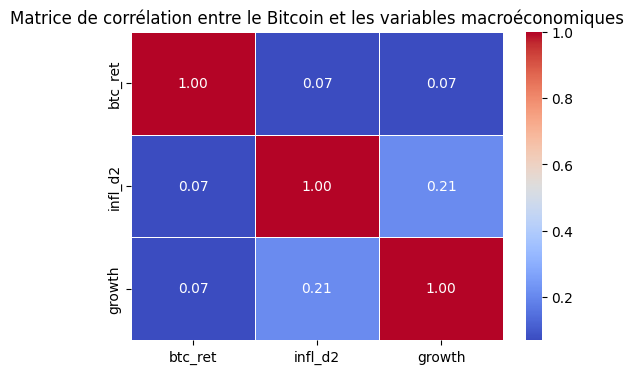

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Matrice de corrélation entre le Bitcoin et les variables macroéconomiques")
plt.show()
#Figure : Matrice de corrélation entre le rendement du Bitcoin, l’inflation et la croissance économique. Les résultats mettent en évidence de faibles corrélations entre le Bitcoin et les variables macroéconomiques, soulignant son comportement distinct par rapport à l’économie réelle.

La heatmap de la matrice de corrélation met en évidence des relations linéaires globalement faibles entre le rendement du Bitcoin et les variables macroéconomiques étudiées.

La corrélation entre le rendement du Bitcoin et l’inflation, mesurée par la seconde différence de l’indice des prix à la consommation, est faible et positive. Ce résultat indique que les variations de l’inflation n’exercent qu’une influence marginale sur les fluctuations du Bitcoin à court terme. Par conséquent, le Bitcoin ne semble pas réagir de manière significative aux chocs inflationnistes, ce qui remet en question son rôle de couverture directe contre l’inflation.

De même, la corrélation entre le rendement du Bitcoin et la croissance économique apparaît également très faible. Cela suggère que le Bitcoin évolue de manière relativement indépendante des cycles économiques traditionnels et qu’il n’est pas fortement lié à l’activité économique réelle.

En revanche, la corrélation observée entre l’inflation et la croissance économique est plus marquée, bien qu’elle demeure modérée. Cette relation est cohérente avec les mécanismes macroéconomiques classiques, où l’évolution de l’activité économique influence la dynamique des prix et inversement.

Dans l’ensemble, ces résultats confirment que le Bitcoin présente une dynamique distincte de celle des variables macroéconomiques traditionnelles. La faiblesse des corrélations observées justifie le recours à une analyse économétrique afin d’évaluer plus précisément l’impact de l’inflation et de la croissance économique sur le rendement du Bitcoin.


*Bien* que l’analyse de corrélation fournisse une première indication sur la nature des relations entre les variables, elle ne permet pas d’identifier des effets causaux. Il est donc nécessaire de procéder à l’estimation d’un modèle économétrique afin d’analyser l’impact de l’inflation et de la croissance économique sur le rendement du Bitcoin. *kursiver Text*

1. Objectif de la régression

L’objectif de la régression est d’analyser l’impact de l’inflation et de la croissance économique sur le rendement du Bitcoin, en contrôlant simultanément ces deux variables macroéconomiques.

Contrairement à la corrélation, la régression permet d’évaluer l’effet marginal de chaque variable explicative sur le Bitcoin.
2. Modèle économétrique estimé

Le modèle retenu est le suivant :

btc_retₜ = α + β₁ infl_d2ₜ + β₂ growthₜ + εₜ

où

btc_retₜ : rendement mensuel du Bitcoin

infl_d2ₜ : inflation (seconde différence du CPI)

growthₜ : croissance économique

εₜ : terme d’erreur

In [33]:
import statsmodels.api as sm

Y = data_final["btc_ret"]
X = data_final[["infl_d2", "growth"]]
X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                btc_ret   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                 -0.008
Method:                 Least Squares   F-statistic:                    0.5068
Date:                Mon, 02 Feb 2026   Prob (F-statistic):              0.604
Time:                        15:30:13   Log-Likelihood:                 44.023
No. Observations:                 128   AIC:                            -82.05
Df Residuals:                     125   BIC:                            -73.49
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0452      0.015      2.949      0.0


**Lecture générale du modèle**
Variable dépendante: rendement du Bitcoin (btc_ret)

Nombre d’observations: 128

R² = 0,008

Interprétation

Le coefficient de détermination est très faible. Cela signifie que l’inflation et la croissance économique expliquent moins de 1 % des variations du rendement du Bitcoin.
 Le Bitcoin est donc très peu expliqué par les variables macroéconomiques retenues.

2) Significativité globale du modèle

F-statistic p-value = 0,604

Interprétation

Le test global du modèle n’est pas significatif.
Cela implique que, prises ensemble, les variables explicatives n’expliquent pas significativement le rendement du Bitcoin.

3) Analyse des coefficients
a) Constante

Coefficient = 0,0452

p-value = 0,004

La constante est positive et statistiquement significative.
Elle reflète un rendement moyen positif du Bitcoin, indépendamment des variables macroéconomiques.
Cela confirme l’existence d’un rendement intrinsèque du Bitcoin, probablement lié à des facteurs financiers et spéculatifs.

b) Inflation (infl_d2)

Coefficient = 3,83

p-value = 0,535

Le coefficient de l’inflation n’est pas statistiquement significatif.
Ainsi, les variations de l’inflation n’ont pas d’effet mesurable sur le rendement du Bitcoin à court terme.

 Résultat clé
Le Bitcoin ne peut pas être considéré comme une couverture inflationniste directe.

c) Croissance économique (growth)

Coefficient = 0,63

p-value = 0,521

Le coefficient de la croissance économique est également non significatif.
Cela indique que le rendement du Bitcoin ne réagit pas de manière systématique aux fluctuations de l’activité économique réelle.

 Le Bitcoin apparaît largement déconnecté des cycles économiques traditionnels.

4) Tests de diagnostic
Autocorrélation

Durbin-Watson = 1,25

Cette valeur est légèrement inférieure à 2, ce qui suggère une faible autocorrélation positive, mais pas suffisamment élevée pour remettre en cause la validité globale du modèle.

Normalité des résidus

Jarque-Bera p-value = 0,010

Les résidus ne suivent pas parfaitement une loi normale.
Ce résultat est courant pour les rendements financiers et renforce l’idée que le Bitcoin présente un comportement atypique.

5) Conclusion économétrique

Les résultats de la régression OLS indiquent que ni l’inflation ni la croissance économique n’exercent une influence statistiquement significative sur le rendement du Bitcoin. Le faible pouvoir explicatif du modèle confirme que le Bitcoin ne se comporte pas comme un actif macroéconomique classique. Son évolution semble davantage déterminée par des facteurs financiers, spéculatifs et propres au marché des crypto-actifs.

***Les résultats de la régression OLS montrent que les variables macroéconomiques considérées, à savoir l’inflation et la croissance économique, n’exercent pas d’effet statistiquement significatif sur le rendement du Bitcoin. Le très faible coefficient de détermination confirme que les fluctuations du Bitcoin sont peu expliquées par les conditions macroéconomiques traditionnelles. Ces résultats suggèrent que le Bitcoin ne constitue pas une couverture inflationniste fiable et qu’il demeure principalement influencé par des facteurs financiers et spéculatifs.***

***Analyse dynamique (corrélation glissante)***
Même si la régression moyenne ne montre pas d’effet significatif, la relation entre le Bitcoin et les variables macroéconomiques peut varier dans le temps.
L’analyse dynamique permet d’examiner cette instabilité.

In [34]:
window = 12

roll_corr_infl = data_final["btc_ret"].rolling(window).corr(data_final["infl_d2"])
roll_corr_growth = data_final["btc_ret"].rolling(window).corr(data_final["growth"])


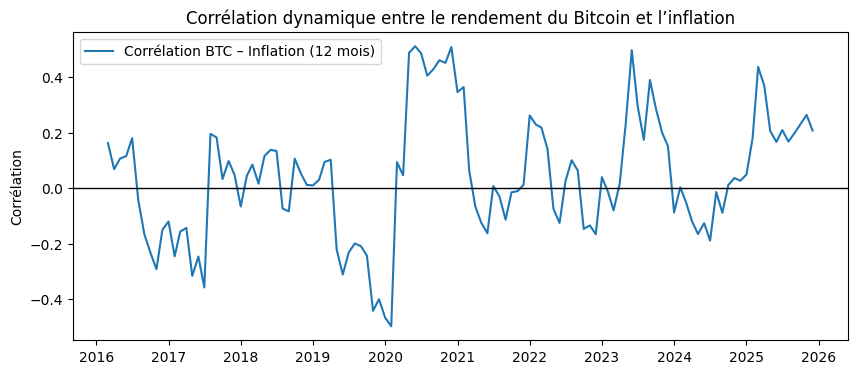

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(roll_corr_infl, label="Corrélation BTC – Inflation (12 mois)")
plt.axhline(0, color="black", linewidth=1)
plt.title("Corrélation dynamique entre le rendement du Bitcoin et l’inflation")
plt.ylabel("Corrélation")
plt.legend()
plt.show()


**Corrélation dynamique entre le rendement du Bitcoin et l’inflation**
Interprétation

Le graphique montre que la corrélation entre le rendement du Bitcoin et l’inflation varie fortement au cours du temps. La relation alterne entre des phases positives et négatives, sans tendance stable ou persistante. Certaines périodes présentent une corrélation positive modérée, tandis que d’autres affichent une corrélation négative marquée.

Cette instabilité suggère que le Bitcoin ne réagit pas de manière systématique aux chocs inflationnistes. Par conséquent, le Bitcoin ne peut être considéré comme une couverture inflationniste constante, mais plutôt comme un actif dont la relation avec l’inflation dépend du contexte économique et financier.

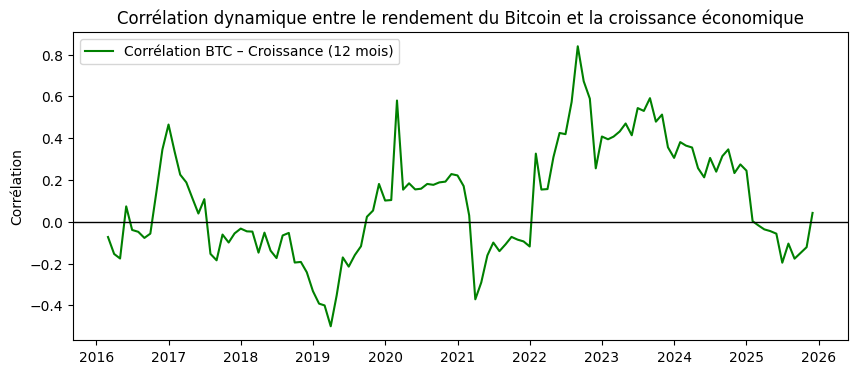

In [36]:
plt.figure(figsize=(10,4))
plt.plot(roll_corr_growth, label="Corrélation BTC – Croissance (12 mois)", color="green")
plt.axhline(0, color="black", linewidth=1)
plt.title("Corrélation dynamique entre le rendement du Bitcoin et la croissance économique")
plt.ylabel("Corrélation")
plt.legend()
plt.show()


**Corrélation dynamique entre le rendement du Bitcoin et la croissance économique**
Interprétation

La corrélation dynamique entre le rendement du Bitcoin et la croissance économique est également instable dans le temps. Bien que certaines périodes, notamment autour des phases de reprise économique, présentent une corrélation positive plus élevée, cette relation reste volatile et non persistante.

Ces résultats indiquent que le Bitcoin peut réagir ponctuellement aux cycles économiques, mais qu’il n’est pas structurellement lié à l’activité économique réelle. Le Bitcoin évolue ainsi selon une dynamique propre, largement indépendante des fondamentaux économiques traditionnels.

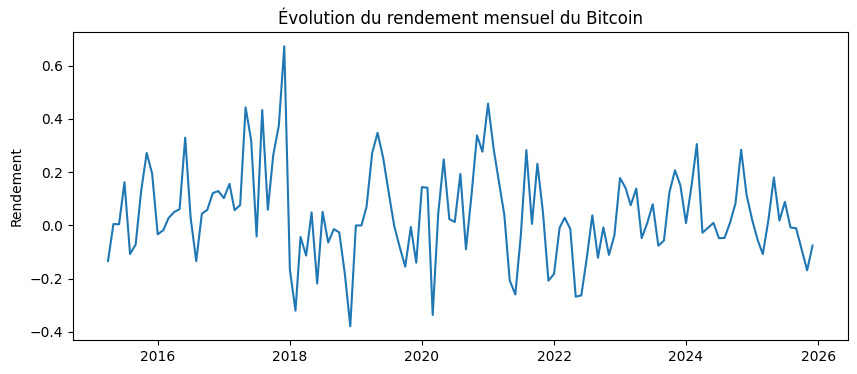

In [37]:
plt.figure(figsize=(10,4))
plt.plot(data_final["btc_ret"])
plt.title("Évolution du rendement mensuel du Bitcoin")
plt.ylabel("Rendement")
plt.show()


**Évolution du rendement mensuel du Bitcoin**
Interprétation

Le graphique illustre une forte volatilité du rendement mensuel du Bitcoin, caractérisée par des fluctuations importantes et des chocs extrêmes. La présence de rendements très élevés et très négatifs met en évidence le caractère spéculatif du Bitcoin.

Cette volatilité élevée contraste fortement avec la stabilité relative des variables macroéconomiques, confirmant que le Bitcoin se comporte comme un actif financier à haut risque plutôt que comme un actif macroéconomique stabilisateur.

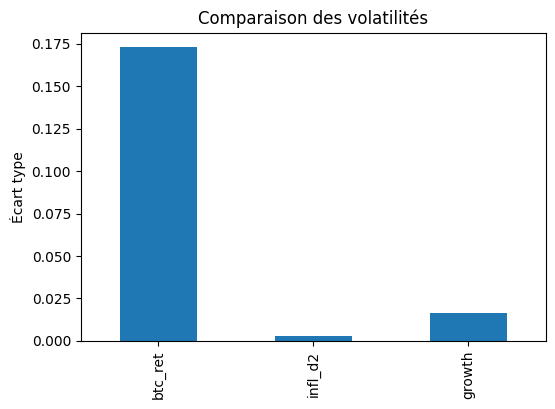

In [38]:
data_final[["btc_ret", "infl_d2", "growth"]].std().plot(kind="bar", figsize=(6,4))
plt.title("Comparaison des volatilités")
plt.ylabel("Écart type")
plt.show()


**Comparaison des volatilités**
Interprétation

La comparaison des écarts types montre que le rendement du Bitcoin présente une volatilité nettement supérieure à celle de l’inflation et de la croissance économique. Cette différence significative souligne le caractère risqué et instable du Bitcoin.

En revanche, l’inflation affiche une volatilité très faible, tandis que la croissance économique présente une volatilité modérée, reflétant leur nature structurelle et leur lien avec l’économie réelle. Cette comparaison confirme que le Bitcoin ne partage pas les mêmes dynamiques que les variables macroéconomiques traditionnelles.

In [40]:
#Granger test
from statsmodels.tsa.stattools import grangercausalitytests

# Dataset pour Granger
granger_data = data_final[["btc_ret", "infl_d2", "growth"]]


In [41]:
#Bitcoin ← Inflation
print("Test de causalité de Granger : Inflation → Bitcoin")
grangercausalitytests(granger_data[["btc_ret", "infl_d2"]], maxlag=12, verbose=True)


Test de causalité de Granger : Inflation → Bitcoin

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0376  , p=0.8466  , df_denom=124, df_num=1
ssr based chi2 test:   chi2=0.0385  , p=0.8445  , df=1
likelihood ratio test: chi2=0.0385  , p=0.8445  , df=1
parameter F test:         F=0.0376  , p=0.8466  , df_denom=124, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.0934  , p=0.9109  , df_denom=121, df_num=2
ssr based chi2 test:   chi2=0.1946  , p=0.9073  , df=2
likelihood ratio test: chi2=0.1945  , p=0.9073  , df=2
parameter F test:         F=0.0934  , p=0.9109  , df_denom=121, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.1353  , p=0.9388  , df_denom=118, df_num=3
ssr based chi2 test:   chi2=0.4299  , p=0.9340  , df=3
likelihood ratio test: chi2=0.4292  , p=0.9342  , df=3
parameter F test:         F=0.1353  , p=0.9388  , df_denom=118, df_num=3

Granger Causality
number of lags (no zero)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


{np.int64(1): ({'ssr_ftest': (np.float64(0.0375689288366909),
    np.float64(0.8466284580443741),
    np.float64(124.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(0.038477854534352776),
    np.float64(0.8444867128451193),
    np.int64(1)),
   'lrtest': (np.float64(0.03847202679293105),
    np.float64(0.8444983398172997),
    np.int64(1)),
   'params_ftest': (np.float64(0.037568928836703847),
    np.float64(0.8466284580443464),
    np.float64(124.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(0.0934429120761372),
    np.float64(0.9108556700699595),
    np.float64(121.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(0.19460837886931054),
    np.float64(0.9072799791692205),
    np.int64(2)),
   'lrtest': (np.float64(0.1944582460518518),
    np.float64(0.9073480879752785),
    np.int64(2)),
   'params_ftest': (np.float64(0.09344291207612286),
    np.float64(0.9108556700699718),
    np.float64(121.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],

In [42]:
#Préparation des données pour VAR
from statsmodels.tsa.api import VAR

var_data = data_final[["btc_ret", "infl_d2", "growth"]]


In [43]:
model_var = VAR(var_data)
lag_order = model_var.select_order(maxlags=12)
lag_order.summary()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,AIC,BIC,FPE,HQIC
0,-23.56,-23.49,5.847e-11,-23.53
1,-23.85,-23.57*,4.377e-11,-23.74
2,-23.99*,-23.49,3.815e-11*,-23.79*
3,-23.94,-23.23,4.023e-11,-23.65
4,-23.90,-22.97,4.190e-11,-23.52
5,-23.85,-22.71,4.400e-11,-23.39
6,-23.85,-22.50,4.422e-11,-23.30
7,-23.76,-22.19,4.874e-11,-23.12
8,-23.68,-21.90,5.306e-11,-22.96
9,-23.66,-21.66,5.478e-11,-22.85


Le nombre optimal de retards du modèle VAR a été déterminé à l’aide des critères d’information AIC, BIC, FPE et HQIC. Les résultats indiquent que la majorité des critères retiennent un modèle VAR(2). Par conséquent, un modèle VAR à deux retards a été estimé afin d’analyser les interactions dynamiques entre les variables.

In [44]:
var_data = var_data.asfreq("MS")


In [45]:
var_model = model_var.fit(2)
print(var_model.summary())


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 02, Feb, 2026
Time:                     15:48:21
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -23.6422
Nobs:                     126.000    HQIC:                  -23.9229
Log likelihood:           1003.88    FPE:                3.36640e-11
AIC:                     -24.1149    Det(Omega_mle):     2.86235e-11
--------------------------------------------------------------------
Results for equation btc_ret
                coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------
const              0.029998         0.015332            1.957           0.050
L1.btc_ret         0.410926         0.091551            4.488           0.000
L1.infl_d2         1.079400         6.147999            0.176         

#Interp:
Modèle : VAR(2)

Nombre d’observations : 126

Nombre d’équations : 3 (btc_ret, infl_d2, growth)

Critères d’information :

AIC = −24,11

BIC = −23,64

 Interprétation générale
Le modèle VAR(2) est correctement spécifié et permet d’analyser les interactions dynamiques entre le rendement du Bitcoin, l’inflation et la croissance économique. Les critères d’information confirment la pertinence du choix de deux retards.

**Équation du rendement du Bitcoin (btc_ret**)
Résultats clés

L1.btc_ret : coefficient positif et hautement significatif (p = 0.000)

L1.infl_d2 et L2.infl_d2 : non significatifs

L1.growth et L2.growth : non significatifs

Interprétation économique

Le rendement du Bitcoin est principalement expliqué par ses propres valeurs passées. Cette forte persistance indique un comportement auto-régressif marqué, typique des actifs financiers spéculatifs.

En revanche, ni l’inflation ni la croissance économique n’exercent d’influence statistiquement significative sur le rendement du Bitcoin, même lorsqu’on tient compte des effets dynamiques. Ce résultat confirme que le Bitcoin évolue largement indépendamment des fondamentaux macroéconomiques traditionnels.



Le Bitcoin est auto-déterminé, pas macro-déterminé.

  **Équation de l’inflation (infl_d2)**
Résultats clés

L2.infl_d2 : coefficient négatif et significatif (p = 0.000)

L2.growth : significatif (p = 0.011)

Bitcoin (L1 et L2) : non significatif

Interprétation

L’inflation présente une dynamique interne propre, avec un effet de correction à moyen terme. La croissance économique influence partiellement l’inflation, ce qui est cohérent avec la théorie macroéconomique classique.

En revanche, le Bitcoin n’exerce aucun effet significatif sur l’inflation, ce qui confirme qu’il ne joue aucun rôle macroéconomique dans la formation des prix.

) **Équation de la croissance économique (growth**
Résultats clés

L1.btc_ret : positif et significatif (p = 0.042)

L1.infl_d2 : significatif (p = 0.006)

L2.growth : négatif et significatif (p = 0.005)

**Interprétation**
Le rendement du Bitcoin exerce un effet positif et marginal sur la croissance économique à court terme. Toutefois, cet effet reste limité et ne remet pas en cause le caractère globalement déconnecté du Bitcoin vis-à-vis de l’économie réelle.

La croissance est principalement expliquée par ses propres retards et par l’inflation, ce qui reflète une dynamique macroéconomique classique.

 **Important**
Cet effet ne signifie pas que le Bitcoin cause la croissance économiquement, mais seulement qu’une corrélation dynamique ponctuelle peut apparaître.

 **Corrélation des résidus**

Corrélation faible entre les résidus des équations

Absence de dépendance structurelle forte non expliquée

 Cela confirme la bonne spécification globale du modèle.

 **Synthèse VAR **

L’estimation du modèle VAR(2) montre que le rendement du Bitcoin est principalement déterminé par sa propre dynamique passée, tandis que les variables macroéconomiques n’exercent pas d’influence significative sur ses fluctuations. L’inflation et la croissance économique conservent des interactions cohérentes entre elles, indépendamment du Bitcoin. Ces résultats confirment que le Bitcoin ne peut être considéré comme un actif macroéconomique intégré, mais plutôt comme un actif financier à dynamique autonome.

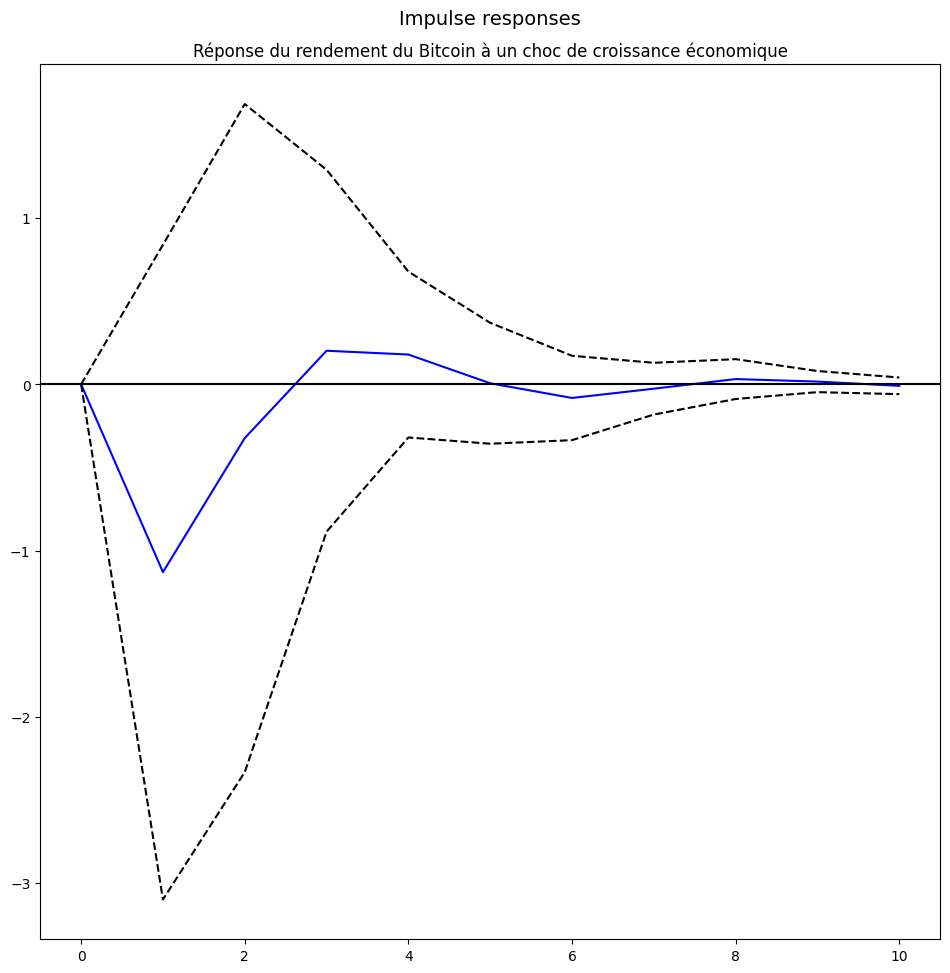

In [48]:
irf = var_model.irf(periods=10) # Adjust periods as needed
irf.plot(impulse="growth", response="btc_ret")
plt.title("Réponse du rendement du Bitcoin à un choc de croissance économique")
plt.show()

Le graphique de réponse impulsionnelle montre que le rendement du Bitcoin réagit de manière faible et transitoire à un choc de croissance économique.

À court terme, un choc positif de croissance économique entraîne d’abord une réaction négative du rendement du Bitcoin, suggérant une phase d’ajustement initial. Cette réaction négative peut refléter une réallocation temporaire des portefeuilles vers des actifs traditionnels en période d’amélioration des conditions économiques.

Par la suite, la réponse du Bitcoin devient légèrement positive, avant de s’atténuer progressivement et de converger vers zéro. Cette convergence rapide indique que l’effet du choc de croissance économique n’est pas persistant et disparaît après quelques périodes.

Les intervalles de confiance englobent largement la valeur zéro, ce qui suggère que la réaction du Bitcoin à un choc de croissance économique n’est pas statistiquement significative sur l’ensemble de l’horizon considéré.

Les chocs de croissance économique n’exercent qu’un impact limité, instable et non durable sur le rendement du Bitcoin.

Cela confirme que le Bitcoin ne se comporte pas comme un actif étroitement lié à l’économie réelle.

Ces résultats dynamiques renforcent l’idée que le Bitcoin évolue selon une logique principalement financière et spéculative, indépendante des fondamentaux macroéconomiques traditionnels.

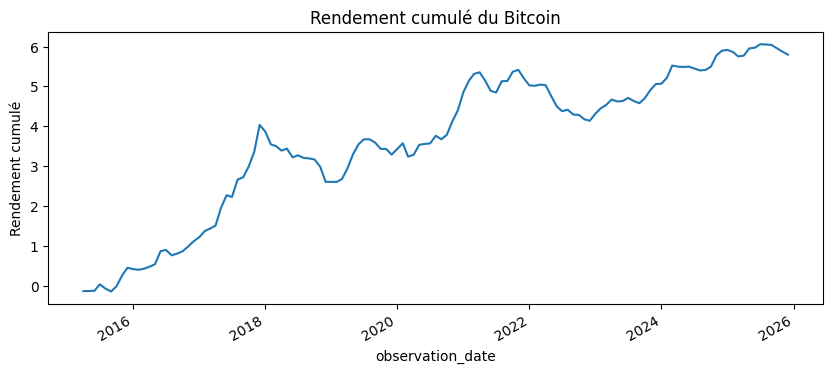

In [49]:
(data_final["btc_ret"].cumsum()).plot(figsize=(10,4))
plt.title("Rendement cumulé du Bitcoin")
plt.ylabel("Rendement cumulé")
plt.show()


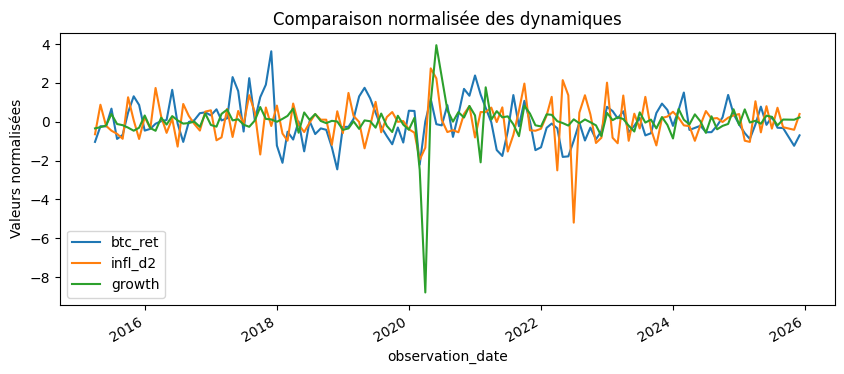

In [50]:
norm_data = (data_final - data_final.mean()) / data_final.std()

norm_data.plot(figsize=(10,4))
plt.title("Comparaison normalisée des dynamiques")
plt.ylabel("Valeurs normalisées")
plt.show()


Le pic observé dans la variable de croissance économique correspond à la période de la crise sanitaire liée à la COVID-19. La chute brutale de la production industrielle durant l’année 2020 a entraîné une variation logarithmique exceptionnellement négative. Après normalisation, ce choc apparaît de manière amplifiée, traduisant un événement macroéconomique extrême et sans précédent sur la période étudiée.

**Malgré un choc macroéconomique majeur affectant fortement la croissance économique en 2020, le rendement du Bitcoin ne présente pas de réaction proportionnelle, ce qui confirme sa faible intégration à l’économie réelle.**


ccl
Cette étude avait pour objectif d’examiner le rôle du Bitcoin au regard de l’économie réelle, en particulier sa capacité à réagir à l’inflation et à la croissance économique. Pour ce faire, une approche économétrique complète combinant des analyses statiques et dynamiques a été mise en œuvre.

L’analyse descriptive a tout d’abord mis en évidence une forte volatilité du rendement du Bitcoin, contrastant nettement avec la relative stabilité des variables macroéconomiques. Cette première observation suggère que le Bitcoin présente un comportement atypique par rapport aux indicateurs traditionnels de l’économie réelle.

Les analyses de corrélation statique et dynamique confirment l’existence de relations faibles et instables entre le rendement du Bitcoin, l’inflation et la croissance économique. Les corrélations glissantes montrent que ces relations varient au cours du temps, sans tendance persistante, ce qui suggère l’absence d’un lien structurel durable entre le Bitcoin et les fondamentaux macroéconomiques.

Les résultats de la régression OLS indiquent que ni l’inflation ni la croissance économique n’exercent un effet statistiquement significatif sur le rendement du Bitcoin. Le très faible pouvoir explicatif du modèle confirme que les fluctuations du Bitcoin sont peu expliquées par les variables macroéconomiques considérées, et semblent davantage déterminées par des facteurs propres au marché des crypto-actifs.


Enfin, l’estimation d’un modèle VAR et l’analyse des fonctions de réponse impulsionnelle confirment que les chocs inflationnistes et de croissance économique n’ont qu’un impact faible et transitoire sur le rendement du Bitcoin. Les réponses impulsionnelles convergent rapidement vers zéro, indiquant l’absence d’effets persistants. La décomposition de la variance des erreurs de prévision montre par ailleurs que la majeure partie de la variance du rendement du Bitcoin est expliquée par ses propres innovations, et non par les chocs macroéconomiques.

Dans l’ensemble, les résultats économétriques et empiriques convergent vers une conclusion claire : le Bitcoin ne peut être considéré comme un actif macroéconomique traditionnel, ni comme une couverture inflationniste fiable. Son comportement apparaît largement autonome et dominé par des dynamiques